In [1]:

# ============================================================
# Cell 1 — Imports & global setup
# ============================================================

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import h5py
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

import random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# Cell 2 — User configuration: file paths & label key
# ============================================================

LABEL_KEY = "Y_Y"  # Key name for labels inside .mat/.h5

TRAIN_FILE_PATHS = [
    "gfli1_impedance_dataset.mat",
    "gfli2_impedance_dataset.mat",
    "gfli3_impedance_dataset.mat",
    "gfli4_impedance_dataset.mat",
    "gfli5_impedance_dataset.mat",
    "gfli6_impedance_dataset.mat",
    "gfli7_impedance_dataset.mat",
    "gfli8_impedance_dataset.mat",
    "gfli9_impedance_dataset.mat",
]

TEST_FILE_PATHS = [
    "gfli1_test_impedance_dataset.mat",
    "gfli2_test_impedance_dataset.mat",
    "gfli3_test_impedance_dataset.mat",
    "gfli4_test_impedance_dataset.mat",
    "gfli5_test_impedance_dataset.mat",
    "gfli6_test_impedance_dataset.mat",
    "gfli7_test_impedance_dataset.mat",
    "gfli8_test_impedance_dataset.mat",
    "gfli9_test_impedance_dataset.mat",
]

print(f"#TRAIN files: {len(TRAIN_FILE_PATHS)}, #TEST files: {len(TEST_FILE_PATHS)}")


# ============================================================
# Cell 3 — IO helpers (.mat / .h5)
# ============================================================

def _fix_shape(arr, expected_cols=None):
    """
    Ensure 2D shape. If expected_cols is given, transpose when needed.
    """
    arr = np.asarray(arr)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    if expected_cols is not None:
        if arr.shape[1] != expected_cols and arr.shape[0] == expected_cols:
            arr = arr.T
    return arr


def _extract_from_h5(f, label_key="Y_Y"):
    """
    Try to extract X (4 cols) and Y (8 cols) from an h5py.File handle.
    Expected structure:
      /Dataset/X, /Dataset/Y_Y (or label_key)
    Fallbacks:
      /X, /Y_Y at root.
    """
    def get_node(g, key):
        return g[key] if key in g else None

    # 1) common path: group 'Dataset' or 'dataset'
    g = get_node(f, "Dataset")
    if g is None:
        g = get_node(f, "dataset")

    if g is not None:
        X = _fix_shape(g["X"][()], expected_cols=4)
        if label_key in g:
            Ysrc = g[label_key]
        else:
            Ysrc = g.get("Y_Y")
        if Ysrc is None:
            raise KeyError("Neither label_key nor 'Y_Y' found under /Dataset")
        Y = _fix_shape(Ysrc[()], expected_cols=8)
        return X, Y

    # 2) fallback: variables at file root
    Xnode = get_node(f, "X")
    Ynode = get_node(f, label_key)
    if Ynode is None:
        Ynode = get_node(f, "Y_Y")

    if Xnode is None or Ynode is None:
        raise KeyError("Could not find X and Y in HDF5 file.")

    X = _fix_shape(Xnode[()], expected_cols=4)
    Y = _fix_shape(Ynode[()], expected_cols=8)
    return X, Y


def _extract_from_mat(d, label_key="Y_Y"):
    """
    Extract from dict returned by scipy.io.loadmat.
    Support:
      - struct Dataset with fields X, Y_Y (or label_key)
      - top-level X, Y_Y
    """
    d2 = {k: v for k, v in d.items() if not k.startswith("__")}

    # struct-like 'Dataset'
    if "Dataset" in d2:
        G = d2["Dataset"]
        if hasattr(G, "dtype") and G.dtype.names:
            fields = G.dtype.names

            def get_field(name):
                if name in fields:
                    val = G[name]
                    val = np.array(val).squeeze()
                    return val
                return None

            X_raw = get_field("X")
            if X_raw is None:
                raise KeyError("Field 'X' not found in Dataset struct.")
            X = _fix_shape(X_raw, expected_cols=4)

            Yraw = get_field(label_key)
            if Yraw is None:
                Yraw = get_field("Y_Y")
            if Yraw is None:
                raise KeyError("Neither label_key nor 'Y_Y' found in Dataset struct.")

            Y = _fix_shape(Yraw, expected_cols=8)
            return X, Y

    # top-level
    X = d2.get("X", None)
    Y = d2.get(label_key, None)
    if Y is None:
        Y = d2.get("Y_Y", None)

    if X is None or Y is None:
        raise KeyError("Could not find X and Y in MAT file (top-level).")

    X = _fix_shape(X, expected_cols=4)
    Y = _fix_shape(Y, expected_cols=8)
    return X, Y


def load_dataset_mat(path, label_key="Y_Y"):
    """
    Load one .mat dataset and return a dict:
      {
        'X': (N,4),
        'Y': (N,8),
        'family': 'GFMI'|'GFLI',
        'ibr': <filename stem>,
        'is_test': True|False
      }
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    lower = path.name.lower()
    family = "GFMI" if "gfmi" in lower else "GFLI"
    is_test = "_test_" in lower
    ibr = path.stem

    # Try HDF5 first
    try:
        with h5py.File(path, "r") as f:
            X, Y = _extract_from_h5(f, label_key=label_key)
            return {"X": X, "Y": Y, "family": family, "ibr": ibr, "is_test": is_test}
    except Exception as e_h5:
        try:
            d = loadmat(str(path))
            X, Y = _extract_from_mat(d, label_key=label_key)
            return {"X": X, "Y": Y, "family": family, "ibr": ibr, "is_test": is_test}
        except Exception as e_mat:
            raise Exception(f"Error loading {path}: h5py-> {e_h5}; loadmat-> {e_mat}")


# ============================================================
# Cell 4 — Load TRAIN / TEST datasets & scaling
# ============================================================

loaded_tr, missing_tr = [], []
for fp in TRAIN_FILE_PATHS:
    try:
        d = load_dataset_mat(fp, LABEL_KEY)
        print(f"[TRAIN] Loaded: {fp} -> X:{d['X'].shape}, Y:{d['Y'].shape}, family={d['family']}")
        loaded_tr.append((fp, d))
    except Exception as e:
        print(f"[TRAIN] Error loading {fp}: {e}")
        missing_tr.append((fp, str(e)))

loaded_te, missing_te = [], []
for fp in TEST_FILE_PATHS:
    try:
        d = load_dataset_mat(fp, LABEL_KEY)
        print(f"[TEST ] Loaded: {fp} -> X:{d['X'].shape}, Y:{d['Y'].shape}, family={d['family']}")
        loaded_te.append((fp, d))
    except Exception as e:
        print(f"[TEST ] Error loading {fp}: {e}")
        missing_te.append((fp, str(e)))

print(f"\nTotal TRAIN loaded: {len(loaded_tr)}, TEST loaded: {len(loaded_te)}")

# Group by family
X_tr_gfmi, Y_tr_gfmi = [], []
X_tr_gfli, Y_tr_gfli = [], []

for fp, d in loaded_tr:
    if d["family"] == "GFMI":
        X_tr_gfmi.append(d["X"])
        Y_tr_gfmi.append(d["Y"])
    elif d["family"] == "GFLI":
        X_tr_gfli.append(d["X"])
        Y_tr_gfli.append(d["Y"])

if not X_tr_gfli:
    raise RuntimeError("Need at least one GFLI dataset in loaded_tr.")

# Stack GFLI to fit scaler
X_tr_gfli_all = np.vstack(X_tr_gfli)
Y_tr_gfli_all = np.vstack(Y_tr_gfli)

# Optional GFMI
if X_tr_gfmi:
    X_tr_gfmi_all = np.vstack(X_tr_gfmi)
    Y_tr_gfmi_all = np.vstack(Y_tr_gfmi)
    X_scaler_gfmi = StandardScaler().fit(X_tr_gfmi_all)
    Y_scaler_gfmi = StandardScaler().fit(Y_tr_gfmi_all)
else:
    X_scaler_gfmi = None
    Y_scaler_gfmi = None

# Scaler cho GFLI
X_scaler_gfli = StandardScaler().fit(X_tr_gfli_all)
Y_scaler_gfli = StandardScaler().fit(Y_tr_gfli_all)

input_dim  = X_tr_gfli_all.shape[1]  # 4
output_dim = Y_tr_gfli_all.shape[1]  # 8
print("Input dim:", input_dim, "| Output dim:", output_dim)


# ============================================================
# Cell 5 — Build clients & test sets
# ============================================================

clients_gfmi = []
clients_gfli = []
cid = 0

# GFMI clients (nếu có)
for fp, d in loaded_tr:
    fam = d["family"]
    X_raw = d["X"]
    Y_raw = d["Y"]

    if fam == "GFMI" and X_scaler_gfmi is not None:
        X_scaled = X_scaler_gfmi.transform(X_raw)
        Y_scaled = Y_scaler_gfmi.transform(Y_raw)
        X_t = torch.from_numpy(X_scaled.astype(np.float32))
        Y_t = torch.from_numpy(Y_scaled.astype(np.float32))
        ds = TensorDataset(X_t, Y_t)
        clients_gfmi.append({
            "id": cid,
            "name": Path(fp).stem,
            "family": fam,
            "dataset": ds,
            "n": X_t.shape[0],
        })
        cid += 1

# GFLI clients (chính cho FL)
for fp, d in loaded_tr:
    fam = d["family"]
    X_raw = d["X"]
    Y_raw = d["Y"]

    if fam == "GFLI":
        X_scaled = X_scaler_gfli.transform(X_raw)
        Y_scaled = Y_scaler_gfli.transform(Y_raw)
        X_t = torch.from_numpy(X_scaled.astype(np.float32))
        Y_t = torch.from_numpy(Y_scaled.astype(np.float32))
        ds = TensorDataset(X_t, Y_t)
        clients_gfli.append({
            "id": cid,
            "name": Path(fp).stem,
            "family": fam,
            "dataset": ds,
            "n": X_t.shape[0],
        })
        cid += 1

print("\nGFLI clients:")
for c in clients_gfli:
    print(f"  id={c['id']}, name={c['name']}, n={c['n']}")

# Build TEST sets (scaled, on device)
test_sets_gfmi = []
test_sets_gfli = []

for fp, d in loaded_te:
    fam = d["family"]
    X_raw = d["X"]
    Y_raw = d["Y"]

    if fam == "GFMI" and X_scaler_gfmi is not None:
        X_scaled = X_scaler_gfmi.transform(X_raw)
        Y_scaled = Y_scaler_gfmi.transform(Y_raw)
        X_t = torch.from_numpy(X_scaled.astype(np.float32))
        Y_t = torch.from_numpy(Y_scaled.astype(np.float32))
        test_sets_gfmi.append({
            "name": Path(fp).stem,
            "family": fam,
            "ibr": d["ibr"],
            "dataset": TensorDataset(X_t, Y_t),
            "X": X_t,
            "Y": Y_t,
            "n": X_t.shape[0],
        })
    elif fam == "GFLI":
        X_scaled = X_scaler_gfli.transform(X_raw)
        Y_scaled = Y_scaler_gfli.transform(Y_raw)
        X_t = torch.from_numpy(X_scaled.astype(np.float32))
        Y_t = torch.from_numpy(Y_scaled.astype(np.float32))
        test_sets_gfli.append({
            "name": Path(fp).stem,
            "family": fam,
            "ibr": d["ibr"],
            "dataset": TensorDataset(X_t, Y_t),
            "X": X_t,
            "Y": Y_t,
            "n": X_t.shape[0],
        })

print(f"\n#TEST GFMI: {len(test_sets_gfmi)}, #TEST GFLI: {len(test_sets_gfli)}")


# ============================================================
# Cell 6 — Model definitions (same full-model structure as fl_scenario_ae_fedavg.py)
# ============================================================

class Trunk(nn.Module):
    def __init__(self, in_dim: int = 4, hidden_dim: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Head(nn.Module):
    def __init__(self, hidden_dim: int = 32, out_dim: int = 8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.ReLU(),
            nn.Linear(16, out_dim),
        )

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        return self.net(h)


class FullModel(nn.Module):
    """Same Trunk + Head full model used by fl_scenario_ae_fedavg.py."""

    def __init__(self, trunk: Trunk, head: Head):
        super().__init__()
        self.trunk = trunk
        self.head = head

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.trunk(x))


class FNN(FullModel):
    """Convenience constructor for the complete FedAvg model."""

    def __init__(self, in_dim: int = 4, hidden_dim: int = 32, out_dim: int = 8):
        super().__init__(Trunk(in_dim, hidden_dim), Head(hidden_dim, out_dim))


HIDDEN_GFLI = 64


# ============================================================
# Cell 7 — Standard FedAvg utilities (aligned with fl_scenario_ae_fedavg.py)
# ============================================================

ROUNDS_FL = 150
LOCAL_EPOCHS_FL = 2
BATCH_SIZE_FL = 128
EVAL_BATCH_SIZE_FL = 512

LR_INIT_FL = 1.5e-3
LR_DECAY1_FL = 700
LR_DECAY2_FL = 800
LR_FACTOR_FL = 0.1
OPTIMIZER_FL = "adam"


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_lr_for_round_fl(r: int) -> float:
    if r <= LR_DECAY1_FL:
        return LR_INIT_FL
    if r <= LR_DECAY2_FL:
        return LR_INIT_FL * LR_FACTOR_FL
    return LR_INIT_FL * LR_FACTOR_FL * 0.5


def clone_state_dict(model: nn.Module):
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}


def get_model_state_dict(model: nn.Module):
    return clone_state_dict(model)


def set_model_state_dict(model: nn.Module, state_dict) -> None:
    model.load_state_dict(state_dict, strict=True)


def aggregate_fedavg(client_states, client_sizes):
    total = float(sum(client_sizes))
    if total <= 0:
        raise ValueError("Cannot aggregate empty client updates.")

    avg_state = {}
    for key in client_states[0].keys():
        avg_state[key] = sum((n / total) * state[key] for state, n in zip(client_states, client_sizes))
    return avg_state


def fedavg_models(model_states, sizes):
    return aggregate_fedavg(model_states, sizes)


def _client_name(client):
    return client["name"] if isinstance(client, dict) else client.name


def _client_dataset(client):
    return client["dataset"] if isinstance(client, dict) else client.dataset


def _client_n(client):
    return int(client["n"] if isinstance(client, dict) else client.n)


def _test_name(test_set):
    return test_set["name"] if isinstance(test_set, dict) else test_set.name


def _test_dataset(test_set):
    if isinstance(test_set, dict):
        if "dataset" in test_set:
            return test_set["dataset"]
        return TensorDataset(test_set["X"].detach().cpu(), test_set["Y"].detach().cpu())
    return test_set.dataset


def train_client_sgd(
    client,
    global_state,
    input_dim: int,
    hidden_dim: int,
    output_dim: int,
    local_epochs: int,
    batch_size: int,
    lr: float,
    optimizer_name: str,
    device: torch.device,
):
    model = FNN(input_dim, hidden_dim, output_dim).to(device)
    model.load_state_dict(global_state, strict=True)
    model.train()

    loader = DataLoader(_client_dataset(client), batch_size=batch_size, shuffle=True)
    criterion = nn.MSELoss()
    if optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    total_loss, total_n = 0.0, 0
    for _ in range(local_epochs):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            total_n += xb.size(0)

    return clone_state_dict(model), total_loss / max(total_n, 1)


def train_one_client_fullmodel(
    client,
    global_model_state,
    hidden_dim,
    epochs=1,
    batch_size=256,
    lr=1e-3,
):
    state, _ = train_client_sgd(
        client=client,
        global_state=global_model_state,
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        local_epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        optimizer_name=OPTIMIZER_FL,
        device=device,
    )
    return state


def evaluate_state(global_state, datasets, input_dim, hidden_dim, output_dim, batch_size, device):
    model = FNN(input_dim, hidden_dim, output_dim).to(device)
    model.load_state_dict(global_state, strict=True)
    model.eval()

    criterion = nn.MSELoss()
    rows = []
    with torch.no_grad():
        for item in datasets:
            loader = DataLoader(_test_dataset(item), batch_size=batch_size, shuffle=False)
            total_loss, total_n = 0.0, 0
            for xb, yb in loader:
                xb = xb.to(device)
                yb = yb.to(device)
                loss = criterion(model(xb), yb)
                total_loss += loss.item() * xb.size(0)
                total_n += xb.size(0)
            rows.append({"name": _test_name(item), "mse": total_loss / total_n, "n": total_n})
    return rows


def evaluate_clients_full(global_model_state, clients, hidden_dim, batch_size=EVAL_BATCH_SIZE_FL):
    rows = evaluate_state(
        global_model_state,
        clients,
        input_dim,
        hidden_dim,
        output_dim,
        batch_size,
        device,
    )
    return [(row["name"], row["mse"]) for row in rows]


def evaluate_tests_full(global_model_state, test_sets, hidden_dim, batch_size=EVAL_BATCH_SIZE_FL):
    rows = evaluate_state(
        global_model_state,
        test_sets,
        input_dim,
        hidden_dim,
        output_dim,
        batch_size,
        device,
    )
    return [(row["name"], row["mse"]) for row in rows]


def run_fedavg_full_gfli(clients, test_sets, hidden_dim, rounds):
    print(f"\n===== Standard FedAvg (full model) for GFLI (rounds={rounds}) =====")

    global_model = FNN(input_dim, hidden_dim, output_dim).to(device)
    global_state = clone_state_dict(global_model)

    history = {
        "round": [],
        "local_train_mse_mean": [],
        "train_mse_mean": [],
        "test_mse_mean": [],
        "train_mse_all": [],
        "test_mse_all": [],
    }

    for r in range(1, rounds + 1):
        lr_round = get_lr_for_round_fl(r)
        model_states, sizes, local_losses = [], [], []

        for c in clients:
            new_state, local_loss = train_client_sgd(
                client=c,
                global_state=global_state,
                input_dim=input_dim,
                hidden_dim=hidden_dim,
                output_dim=output_dim,
                local_epochs=LOCAL_EPOCHS_FL,
                batch_size=BATCH_SIZE_FL,
                lr=lr_round,
                optimizer_name=OPTIMIZER_FL,
                device=device,
            )
            model_states.append(new_state)
            sizes.append(_client_n(c))
            local_losses.append(local_loss)

        global_state = aggregate_fedavg(model_states, sizes)
        train_res = evaluate_clients_full(global_state, clients, hidden_dim)
        test_res = evaluate_tests_full(global_state, test_sets, hidden_dim)

        train_mses = [m for _, m in train_res]
        test_mses = [m for _, m in test_res] if test_res else []
        train_mse_mean = float(np.mean(train_mses))
        test_mse_mean = float(np.mean(test_mses)) if test_mses else float("nan")

        history["round"].append(r)
        history["local_train_mse_mean"].append(float(np.mean(local_losses)))
        history["train_mse_mean"].append(train_mse_mean)
        history["test_mse_mean"].append(test_mse_mean)
        history["train_mse_all"].append(train_mses)
        history["test_mse_all"].append(test_mses)

        print(
            f"[FULL FedAvg] Round {r:03d} | "
            f"local={history['local_train_mse_mean'][-1]:.4e} | "
            f"train={train_mse_mean:.4e} | test={test_mse_mean:.4e}"
        )

    return global_state, history


# ============================================================
# Cell 8 — Helpers for Scenario B (new client join, fairness)
# ============================================================

def compute_fairness_jain(mse_list, eps=1e-8):
    mse_arr = np.array(mse_list, dtype=np.float64)
    util = 1.0 / (mse_arr + eps)
    num = np.square(util.sum())
    den = len(util) * np.square(util).sum()
    return float(num / den)


def _split_old_new_test_mse(test_res_all, name_new_prefix):
    mse_old = []
    mse_new = None
    for tname, mse in test_res_all:
        if tname.lower().startswith(name_new_prefix):
            mse_new = float(mse)
        else:
            mse_old.append(float(mse))
    test_mse_mean_old = float(np.mean(mse_old)) if mse_old else float("nan")
    if mse_new is None:
        mse_new = float("nan")
    return test_mse_mean_old, mse_new


# ============================================================
# Cell 9 — Scenario B: Join vs NoJoin with standard FedAvg
# ============================================================

def run_fedavg_pretrain_old(
    clients_old,
    test_sets,
    name_new_prefix,
    hidden_dim=HIDDEN_GFLI,
    rounds_pre=50,
    tag="FedAvg-Pretrain-OldOnly",
):
    print(f"\n===== {tag} | rounds_pre={rounds_pre} =====")

    global_model = FNN(input_dim, hidden_dim, output_dim).to(device)
    global_state = clone_state_dict(global_model)

    history = {
        "round": [],
        "lr": [],
        "selected_clients": [],
        "local_train_mse_mean": [],
        "test_mse_mean_old": [],
        "test_mse_new": [],
    }

    for r in range(1, rounds_pre + 1):
        lr_round = get_lr_for_round_fl(r)
        model_states, sizes, local_losses = [], [], []

        for c in clients_old:
            new_state, local_loss = train_client_sgd(
                client=c,
                global_state=global_state,
                input_dim=input_dim,
                hidden_dim=hidden_dim,
                output_dim=output_dim,
                local_epochs=LOCAL_EPOCHS_FL,
                batch_size=BATCH_SIZE_FL,
                lr=lr_round,
                optimizer_name=OPTIMIZER_FL,
                device=device,
            )
            model_states.append(new_state)
            sizes.append(_client_n(c))
            local_losses.append(local_loss)

        global_state = aggregate_fedavg(model_states, sizes)
        test_res_all = evaluate_tests_full(global_state, test_sets, hidden_dim)
        test_mse_mean_old, mse_new = _split_old_new_test_mse(test_res_all, name_new_prefix)

        history["round"].append(r)
        history["lr"].append(lr_round)
        history["selected_clients"].append(len(clients_old))
        history["local_train_mse_mean"].append(float(np.mean(local_losses)))
        history["test_mse_mean_old"].append(test_mse_mean_old)
        history["test_mse_new"].append(mse_new)

        print(
            f"[{tag}] Round {r:03d} | clients={len(clients_old)} | "
            f"local={history['local_train_mse_mean'][-1]:.4e} | "
            f"test_old_mean={test_mse_mean_old:.4e} | test_new={mse_new:.4e}"
        )

    return global_state, history


def continue_fedavg_from_state(
    global_state_init,
    clients_old,
    client_new,
    test_sets,
    name_new_prefix,
    hidden_dim=HIDDEN_GFLI,
    start_round=50,
    rounds_total=ROUNDS_FL,
    join_new=False,
    history_pre=None,
    tag="FedAvg-Continue",
):
    print(f"\n===== {tag} | join_new={join_new}, from round {start_round + 1} to {rounds_total} =====")

    global_state = {k: v.clone() for k, v in global_state_init.items()}
    if history_pre is not None:
        history = {k: list(v) for k, v in history_pre.items()}
    else:
        history = {
            "round": [],
            "lr": [],
            "selected_clients": [],
            "local_train_mse_mean": [],
            "test_mse_mean_old": [],
            "test_mse_new": [],
        }

    all_clients = clients_old + [client_new]

    for r in range(start_round + 1, rounds_total + 1):
        lr_round = get_lr_for_round_fl(r)
        active_clients = all_clients if join_new else clients_old
        model_states, sizes, local_losses = [], [], []

        for c in active_clients:
            new_state, local_loss = train_client_sgd(
                client=c,
                global_state=global_state,
                input_dim=input_dim,
                hidden_dim=hidden_dim,
                output_dim=output_dim,
                local_epochs=LOCAL_EPOCHS_FL,
                batch_size=BATCH_SIZE_FL,
                lr=lr_round,
                optimizer_name=OPTIMIZER_FL,
                device=device,
            )
            model_states.append(new_state)
            sizes.append(_client_n(c))
            local_losses.append(local_loss)

        global_state = aggregate_fedavg(model_states, sizes)
        test_res_all = evaluate_tests_full(global_state, test_sets, hidden_dim)
        test_mse_mean_old, mse_new = _split_old_new_test_mse(test_res_all, name_new_prefix)

        history["round"].append(r)
        history["lr"].append(lr_round)
        history["selected_clients"].append(len(active_clients))
        history["local_train_mse_mean"].append(float(np.mean(local_losses)))
        history["test_mse_mean_old"].append(test_mse_mean_old)
        history["test_mse_new"].append(mse_new)

        print(
            f"[{tag}] Round {r:03d} | clients={len(active_clients)} | "
            f"local={history['local_train_mse_mean'][-1]:.4e} | "
            f"test_old_mean={test_mse_mean_old:.4e} | test_new={mse_new:.4e}"
        )

    return global_state, history


# ============================================================
# Cell 10 — Chọn old/new client
# ============================================================

set_seed(SEED)

# New client: gfli1 (IBR1)
client_new_full = None
for c in clients_gfli:
    if c["name"].lower().startswith("gfli1"):
        client_new_full = c
        break

if client_new_full is None:
    raise RuntimeError("Không tìm thấy client có tên bắt đầu bằng 'gfli1' trong clients_gfli.")

# Old clients = các IBR còn lại (gfli2..gfli9)
clients_old = [c for c in clients_gfli if c["name"] != client_new_full["name"]]

print("\nOld clients:")
for c in clients_old:
    print(f"  {c['name']} (n={c['n']})")
print(f"New client (full): {client_new_full['name']} (n={client_new_full['n']})")

FRAC_NEW_DATA = 1.0


def subsample_client(client, frac=0.1):
    ds = client["dataset"]
    X, Y = ds.tensors
    n = X.shape[0]
    k = max(1, int(n * frac))
    idx = torch.randperm(n)[:k]
    ds_small = TensorDataset(X[idx], Y[idx])
    new_client = dict(client)
    new_client["dataset"] = ds_small
    new_client["n"] = k
    return new_client


client_new = subsample_client(client_new_full, frac=FRAC_NEW_DATA)
print(f"New client (subsampled): {client_new['name']} (n={client_new['n']})")

name_new_full = client_new["name"].lower()
name_new_prefix = name_new_full.split("_")[0]


# ============================================================
# Cell 11 — Run Scenario B; figures are kept in plot_scenario_b.py
# ============================================================

JOIN_ROUND = 20

global_state_at_join, history_pre = run_fedavg_pretrain_old(
    clients_old=clients_old,
    test_sets=test_sets_gfli,
    name_new_prefix=name_new_prefix,
    hidden_dim=HIDDEN_GFLI,
    rounds_pre=JOIN_ROUND,
    tag="FedAvg-Pretrain-OldOnly",
)

global_state_nojoin, hist_nojoin = continue_fedavg_from_state(
    global_state_init=global_state_at_join,
    clients_old=clients_old,
    client_new=client_new,
    test_sets=test_sets_gfli,
    name_new_prefix=name_new_prefix,
    hidden_dim=HIDDEN_GFLI,
    start_round=JOIN_ROUND,
    rounds_total=ROUNDS_FL,
    join_new=False,
    history_pre=history_pre,
    tag="FedAvg-NoJoin",
)

global_state_join, hist_join = continue_fedavg_from_state(
    global_state_init=global_state_at_join,
    clients_old=clients_old,
    client_new=client_new,
    test_sets=test_sets_gfli,
    name_new_prefix=name_new_prefix,
    hidden_dim=HIDDEN_GFLI,
    start_round=JOIN_ROUND,
    rounds_total=ROUNDS_FL,
    join_new=True,
    history_pre=history_pre,
    tag="FedAvg-Join",
)

rounds_axis = np.array(hist_join["round"])


Using device: cuda
#TRAIN files: 9, #TEST files: 9
[TRAIN] Loaded: gfli1_impedance_dataset.mat -> X:(390, 4), Y:(390, 8), family=GFLI
[TRAIN] Loaded: gfli2_impedance_dataset.mat -> X:(330, 4), Y:(330, 8), family=GFLI
[TRAIN] Loaded: gfli3_impedance_dataset.mat -> X:(297, 4), Y:(297, 8), family=GFLI
[TRAIN] Loaded: gfli4_impedance_dataset.mat -> X:(100, 4), Y:(100, 8), family=GFLI
[TRAIN] Loaded: gfli5_impedance_dataset.mat -> X:(330, 4), Y:(330, 8), family=GFLI
[TRAIN] Loaded: gfli6_impedance_dataset.mat -> X:(220, 4), Y:(220, 8), family=GFLI
[TRAIN] Loaded: gfli7_impedance_dataset.mat -> X:(140, 4), Y:(140, 8), family=GFLI
[TRAIN] Loaded: gfli8_impedance_dataset.mat -> X:(180, 4), Y:(180, 8), family=GFLI
[TRAIN] Loaded: gfli9_impedance_dataset.mat -> X:(40, 4), Y:(40, 8), family=GFLI
[TEST ] Loaded: gfli1_test_impedance_dataset.mat -> X:(780, 4), Y:(780, 8), family=GFLI
[TEST ] Loaded: gfli2_test_impedance_dataset.mat -> X:(627, 4), Y:(627, 8), family=GFLI
[TEST ] Loaded: gfli3_test_i

Stability: hệ thống FL ổn định, không phá old clients khi có client mới join.

Benefit for newcomer: client mới được lợi khi tham gia FL (test MSE thấp hơn zero-shot).
Adding a new client does not harm existing clients, and can even slightly improve their performance.

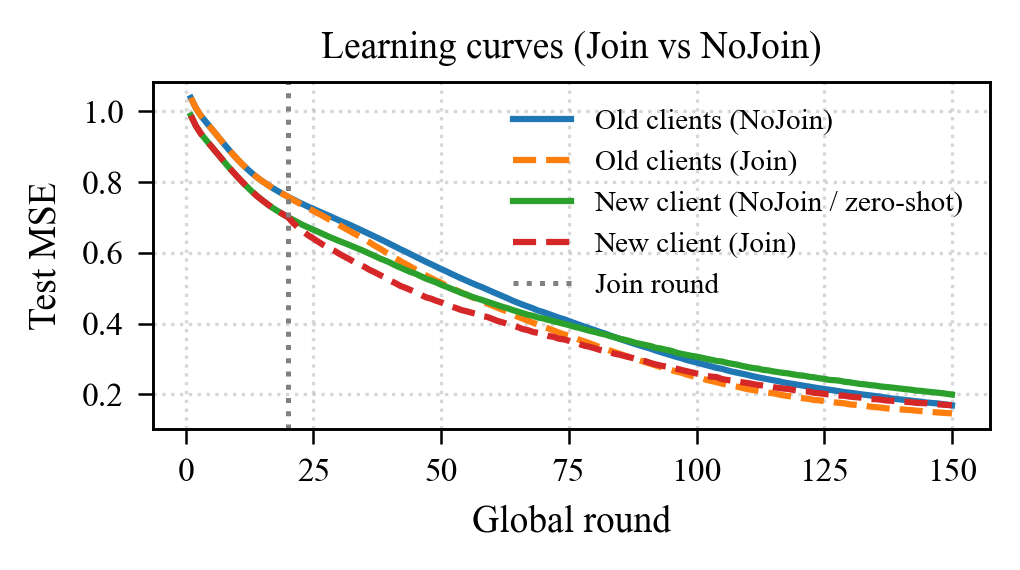


Evaluating per-client test MSE for Join vs NoJoin ...
Final per-client test MSE (NoJoin -> Join):
  gfli1_test_impedance_dataset: 1.9960e-01 -> 1.6914e-01 (impr +15.26% )
  gfli2_test_impedance_dataset: 2.6293e-01 -> 2.2239e-01 (impr +15.42% )
  gfli3_test_impedance_dataset: 1.3812e-01 -> 1.2196e-01 (impr +11.70% )
  gfli4_test_impedance_dataset: 8.2583e-02 -> 7.6176e-02 (impr +7.76% )
  gfli5_test_impedance_dataset: 1.5956e-01 -> 1.2686e-01 (impr +20.49% )
  gfli6_test_impedance_dataset: 1.2779e-01 -> 1.0788e-01 (impr +15.59% )
  gfli7_test_impedance_dataset: 2.1968e-01 -> 1.8475e-01 (impr +15.90% )
  gfli8_test_impedance_dataset: 1.1854e-01 -> 1.1620e-01 (impr +1.98% )
  gfli9_test_impedance_dataset: 2.4452e-01 -> 2.1526e-01 (impr +11.97% )
Jain fairness: NoJoin=0.8736, Join=0.8931


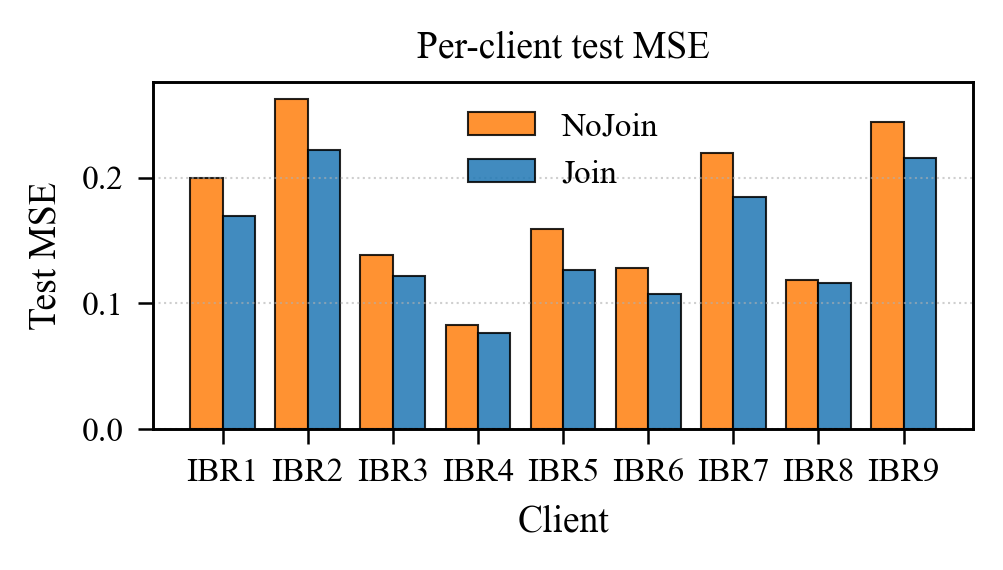

C:\Users\ACER\OneDrive - Umich\My PhD\Research\Topic discussion\Impedance-based Stability Analysis\ML_basedIMEst\FL\CodeImplement\plot_scenario_b.py:215: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(


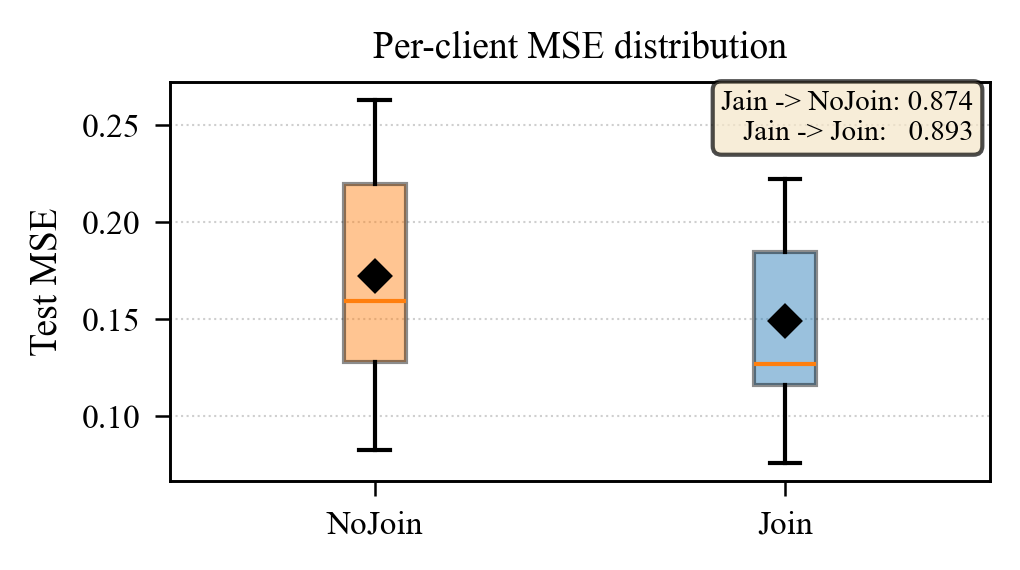

In [2]:
%run -i plot_scenario_b.py